In [1]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q
%pip install scikit-image -q

  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-gmiqvzc8
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-gmiqvzc8
  Resolved https://www.github.com/mouseland/cellpose.git to commit a9f8bfcde43033247309e3982747df9fe9f09315
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 135.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 95.5 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.1-py3-none-any.whl size=213288 sha256=ef166ed1a53686e27a026b086d22c039d619a16f232248eb583c525b78c79ed9
  Stored in directory: /tmp/pip-ephem-wheel-cache-f7a0kaek/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
  Preparing metadata (setup.py) ... done


In [17]:
import owncloud, getpass, cellpose

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [3]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


Tue Apr 14 11:39:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
oc.upload_data()

In [19]:
oc.upload_scripts()

In [20]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tool


from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [21]:

oc.upload_models()

In [8]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

>>> GPU activated? YES


In [7]:
import json

with open('./data/dataset_splits.json', 'r') as f:
    splits = json.load(f)

ids_train = splits['train']
ids_val   = splits['val']
ids_test  = splits['test']

print(f"Splits chargés : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")

Splits chargés : Train(71) | Val(10) | Test(21)


In [ ]:

io.logger_setup()

model = models.CellposeModel(gpu=True)

path = '001'
img = visualizer.load_data(path, target='Image')

masks_pred, flows, styles = model.eval(img, niter=1000)


output_dir = './data/prediction/cellpose4/'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks_pred)

print(f"Masque sauvegardé : {save_path}")

2026-03-20 10:58:34,385 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-20 10:58:34,388 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-20 10:58:34,389 [INFO] ** TORCH CUDA version installed and working. **
2026-03-20 10:58:34,390 [INFO] >>>> using GPU (CUDA)
2026-03-20 10:58:36,678 [INFO] >>>> loading model /root/.cellpose/models/cpsam
Masque sauvegardé : ./data/prediction/cellpose4/001_Cell_pred.bmp


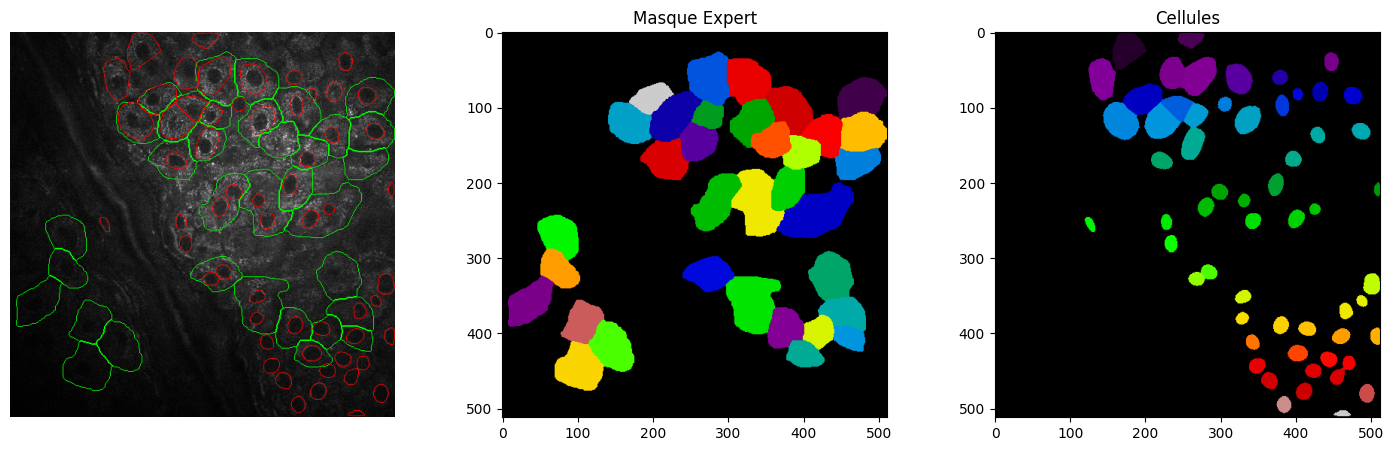

[Cellpose4] F1: 0.087 | TP: 4 | FN: 30


{'f1': 0.08695652335882187,
 'ap': 0.04545454680919647,
 'tp': 4,
 'fp': 54,
 'fn': 30}

In [ ]:
true_mask = visualizer.load_data("001", target='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks_pred, ax=ax1, show=False)
visualizer.plot(data = masks_pred, target = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", target='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()


In [8]:

import random


my_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010','011', '012', '013', '014', '015', '016', '017', '018', '019', '020','021', '022', '023', '024', '025', '026', '027', '028', '029', '030','031', '032', '033', '034', '035', '036', '037', '038', '039', '040','041', '042', '043', '044', '045', '046', '047', '048', '049', '050'] 


random.seed(42)
random.shuffle(my_ids)

n = len(my_ids)
ids_train = my_ids[:int(0.7 * n)]
ids_val   = my_ids[int(0.7 * n):int(0.8 * n)]
ids_test  = my_ids[int(0.8 * n):]

print(f"Split : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")



Split : Train(35) | Val(5) | Test(10)


2026-03-31 14:04:26,077 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 14:04:26,078 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
--- Test LR = 5e-05 ---
2026-03-31 14:04:26,098 [WARNING] model_type argument is not used in v4.0.1+. Ignoring this argument...
2026-03-31 14:04:26,100 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 14:04:26,100 [INFO] >>>> using GPU (CUDA)
2026-03-31 14:04:28,061 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-31 14:04:28,629 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-31 14:04:28,638 [INFO] computing flows for labels


100%|██████████| 35/35 [00:03<00:00,  9.81it/s]

2026-03-31 14:04:32,225 [INFO] computing flows for labels



100%|██████████| 5/5 [00:00<00:00,  9.91it/s]

2026-03-31 14:04:32,735 [INFO] >>> computing diameters


...


100%|██████████| 5/5 [00:00<00:00,  9.83it/s]

2026-03-31 14:14:04,557 [INFO] >>> computing diameters



100%|██████████| 5/5 [00:00<00:00, 778.19it/s]

2026-03-31 14:14:04,611 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-31 14:14:05,064 [INFO] >>> n_epochs=20, n_train=35, n_test=5
2026-03-31 14:14:05,064 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-31 14:14:05,066 [INFO] >>> saving model to models/test_lr_5e-06
2026-03-31 14:14:18,865 [INFO] 0, train_loss=4.1677, test_loss=3.9382, LR=0.000000, time 13.80s
2026-03-31 14:15:25,911 [INFO] 5, train_loss=2.8512, test_loss=2.2922, LR=0.000003, time 80.84s
2026-03-31 14:16:33,069 [INFO] 10, train_loss=2.0420, test_loss=2.0554, LR=0.000005, time 148.00s
2026-03-31 14:18:32,795 [INFO] saving network parameters to models/test_lr_5e-06
2026-03-31 14:18:41,926 [INFO] >>> converting network back to torch.bfloat16 after training
2026-03-31 14:18:41,946 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-31 14:18:42,685 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-03-31 14:18:43,366 

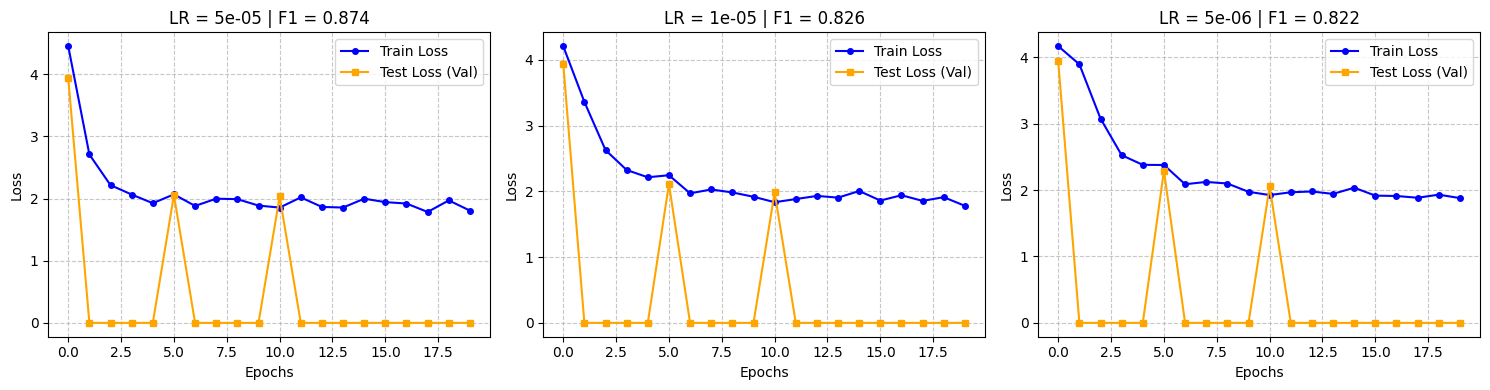

Summary
LR: 5e-05 -> F1-Score: 0.8740
LR: 1e-05 -> F1-Score: 0.8261
LR: 5e-06 -> F1-Score: 0.8221


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io
ev = tool.Stats()

X_train, Y_train = visualizer.load_channel(ids_train, mode= 'raw',target='Image')
X_val, Y_val     = visualizer.load_channel(ids_val, mode = 'raw',target='Image')

io.logger_setup()
learning_rates = [ 0.00005,0.00001,0.000005] 
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

resultats_lr = {}

for i, lr in enumerate(learning_rates):
    print(f"--- Test LR = {lr} ---")
    
    model = models.CellposeModel(model_type='cpsam', gpu=True)
    
    m_path, t_loss, v_loss = train.train_seg(
        model.net,
        train_data=X_train, train_labels=Y_train,
        test_data=X_val, test_labels=Y_val,
        n_epochs=20,         
        learning_rate=lr,
        weight_decay=0.0001,
        save_path='.',
        model_name=f'test_lr_{lr}'
    )
    
    total_tp, total_fp, total_fn = 0, 0, 0
    
    for idx, img_val in enumerate(X_val):
        true_mask = Y_val[idx]

        mask_pred, _, _ = model.eval(img_val, resample=True, channels=[1, 2])
        
        perf = ev.summary_perf(true_mask, mask_pred, iou_threshold=0.5)
        total_tp += perf['tp']
        total_fp += perf['fp']
        total_fn += perf['fn']
        
    if (total_tp + total_fp + total_fn) > 0:
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    else:
        f1_score = 0.0
        
    resultats_lr[lr] = f1_score
    
    visualizer.plot_loss(t_loss, v_loss, title=f"LR = {lr} | F1 = {f1_score:.3f}", ax=axes[i], show=False)

plt.tight_layout()
plt.show()

# Affichage du résumé
print("Summary")
for lr, f1 in resultats_lr.items():
    print(f"LR: {lr} -> F1-Score: {f1:.4f}")

2026-03-23 11:05:20,282 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-23 11:05:20,283 [INFO] 
cellpose version: 	4.0.10.dev21+g849ca11f1 
platform:       	linux 
python version: 	3.12.12 
torch version:  	2.10.0+cu128
2026-03-23 11:05:20,284 [INFO] ** TORCH CUDA version installed and working. **
2026-03-23 11:05:20,285 [INFO] >>>> using GPU (CUDA)
2026-03-23 11:05:22,407 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-03-23 11:05:26,436 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-23 11:05:26,446 [INFO] computing flows for labels


100%|██████████| 71/71 [00:13<00:00,  5.08it/s]

2026-03-23 11:05:40,487 [INFO] computing flows for labels



100%|██████████| 10/10 [00:01<00:00,  5.44it/s]

2026-03-23 11:05:42,337 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 791.03it/s]

2026-03-23 11:05:42,444 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-23 11:05:42,969 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-03-23 11:05:42,970 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-23 11:05:42,973 [INFO] >>> saving model to models/cyto4_100
2026-03-23 11:06:46,454 [INFO] 0, train_loss=4.1617, test_loss=3.9777, LR=0.000000, time 63.48s
2026-03-23 11:11:56,646 [INFO] 5, train_loss=2.3757, test_loss=1.8942, LR=0.000006, time 373.67s
2026-03-23 11:17:06,396 [INFO] 10, train_loss=2.0048, test_loss=1.8421, LR=0.000010, time 683.42s
2026-03-23 11:27:23,890 [INFO] 20, train_loss=1.9327, test_loss=1.7995, LR=0.000010, time 1300.92s
2026-03-23 11:37:42,189 [INFO] 30, train_loss=1.8718, test_loss=1.7705, LR=0.000010, time 1919.22s
2026-03-23 11:46:55,208 [INFO] saving network parameters to models/cyto4_100
2026-03-23 11:47:11,531 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle sauvegardé : models/cyto4_100


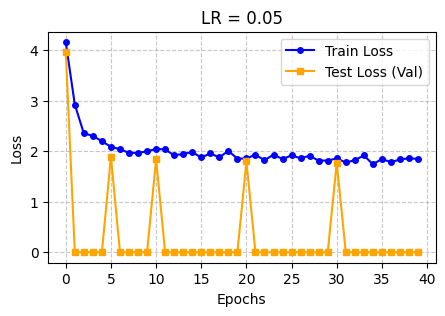

<Axes: title={'center': 'LR = 0.05'}, xlabel='Epochs', ylabel='Loss'>

In [ ]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train)
X_val,Y_val   = visualizer.load_set(ids_val)

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate= 1e-5,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cyto4_100'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


2026-04-01 12:59:02,450 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-01 12:59:02,450 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-01 12:59:02,452 [INFO] ** TORCH CUDA version installed and working. **
2026-04-01 12:59:02,452 [INFO] >>>> using GPU (CUDA)
2026-04-01 12:59:04,576 [INFO] >>>> loading model ./models/cyto4_50.pth
Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...

RESULTATS GLOBAUX : Cellpose4 cell
Images evaluees          : 10
Total Vrais Positifs (TP): 263
Total Faux Positifs (FP) : 51
Total Faux Negatifs (FN) : 26
--------------------------------------------------
F1-Score Global (Micro)  : 0.872
F1-Score Moyen (Macro)   : 0.876



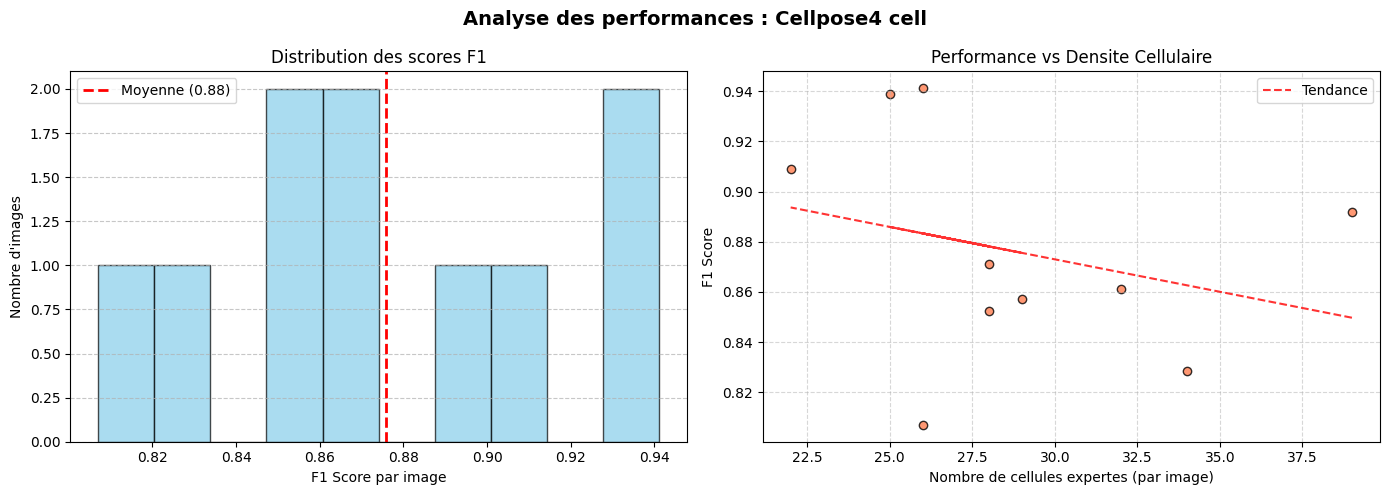

In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='./models/cyto4_50.pth')

base_output = './data/prediction/cellpose4_cyto/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, target='Image')
    true_mask = visualizer.load_data(img_id, target='Cell')
    
    masks, flows, styles = model.eval(img, resample=True,flow_threshold=0.4, cellprob_threshold=0.0)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Cell')
    ax2.set_title("B. Superposition ( vert expert, rouge cellpose)")
    
    visualizer.plot(i=img_id, target='Cell', ax=ax3, show=False)
    ax3.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, target='Cell_pred', ax=ax4, show=False)
    ax4.set_title("D. Prédiction Cellpose ")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

df_final = ev.global_report(all_results, model_name=f"Cellpose4 cell")

In [13]:
oc.download_path('/content/data/prediction/cellpose4_cyto/','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_cyto')

Dossier cellpose4_cyto envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_cyto.zip


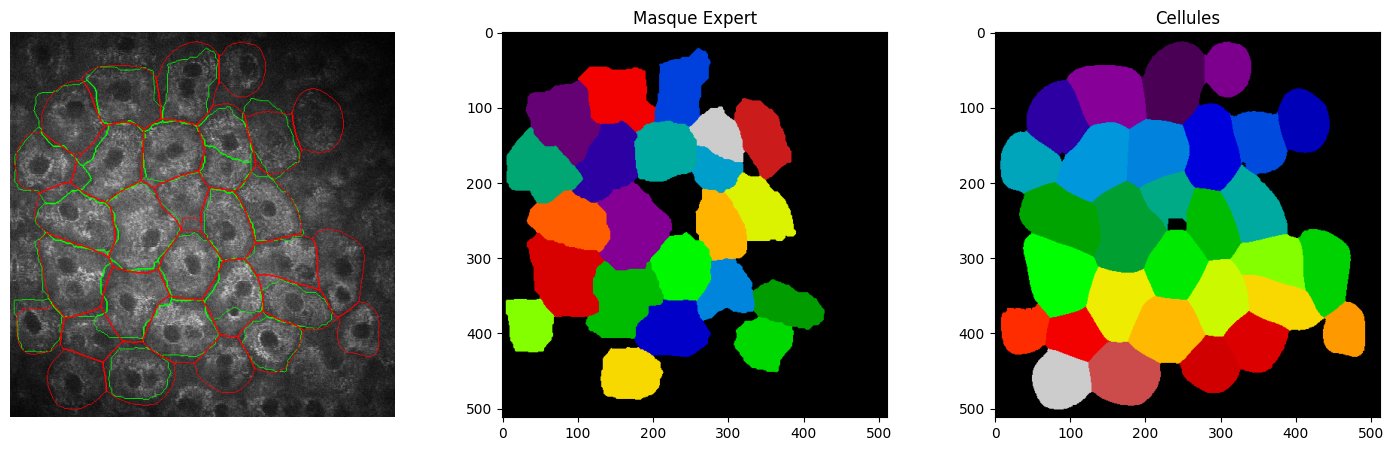

In [ ]:
img_id = '065'
img = visualizer.load_data(img_id, target='Image')
true_mask = visualizer.load_data(img_id, target='Cell')
masks, flows, styles = model.eval(img, resample=True)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax1, show=False)
visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
visualizer.plot(i=img_id, target='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()

In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='./models/cyto4_50.pth')

base_output = './data/prediction/cellpose4_50/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, target='Image')
    true_mask = visualizer.load_data(img_id, target='Cell')
    
    masks, flows, styles = model.eval(img, resample=True)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax4, show=False)
    ax4.set_title("B. Superposition")
    
    visualizer.plot(i=img_id, target='Cell', ax=ax2, show=False)
    ax2.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
    ax3.set_title("D. Prédiction Cellpose ( vert expert, rouge cellpose)")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

creating new log file
2026-03-26 09:34:54,060 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-26 09:34:54,062 [INFO] 
cellpose version: 	4.1.0 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-26 09:34:54,523 [INFO] ** TORCH CUDA version installed and working. **
2026-03-26 09:34:54,525 [INFO] >>>> using GPU (CUDA)
2026-03-26 09:34:57,065 [INFO] >>>> loading model ./models/cyto4_50.pth
Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...


In [ ]:
oc.download_path('/content/data/prediction/cellpose4_50/','/travail/Mines/DIMA/Segmentation/data/prediction/DIMA_cellposeSAM_val')

Dossier cellpose4_50 envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/DIMA_cellposeSAM_val.zip


In [ ]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

# Définition des modes à évaluer
modes_experimentaux = ['top_hat']

io.logger_setup()

for mode_actuel in modes_experimentaux:
    
    print(f"--- ENTRAÎNEMENT : target {mode_actuel} ---")

    X_train, Y_train = visualizer.load_channel(ids_train, target=mode_actuel)
    X_val, Y_val     = visualizer.load_set(ids_val, target='Cell')

    nom_modele = f'cyto4_40_n4_{mode_actuel.lower()}'

    # 3. Entraînement
    model_finetune = models.CellposeModel(gpu=True)

    model_path, t_loss, v_loss = train.train_seg(
        model_finetune.net,
        train_data=X_train,
        train_labels=Y_train,
        test_data=X_val,
        test_labels=Y_val,
        n_epochs=40,          
        learning_rate= 1e-5,
        weight_decay=0.0001,  
        save_path='.',
        model_name=nom_modele
    )

    print(f"Modèle {mode_actuel} sauvegardé avec succès : {model_path}")

    oc.oc.put_file(
        f'/travail/Mines/DIMA/Segmentation/results/models/{nom_modele}.pth',
        model_path, timeout=900
    )

    titre_graphique = f"Courbe de Perte - target {mode_actuel.upper()} (LR = 0.05)"
    visualizer.plot_loss(t_loss, v_loss, title=titre_graphique, show=True)

print("\nProcessus de benchmarking terminé pour les trois modes.")

creating new log file
2026-04-13 06:35:26,771 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-13 06:35:26,772 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
--- ENTRAÎNEMENT : MODE top_hat ---
2026-04-13 06:37:44,436 [INFO] ** TORCH CUDA version installed and working. **
2026-04-13 06:37:44,437 [INFO] >>>> using GPU (CUDA)
2026-04-13 06:37:47,059 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:04<00:00, 265MB/s] 


2026-04-13 06:37:52,866 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-13 06:37:52,876 [INFO] computing flows for labels


100%|██████████| 71/71 [00:07<00:00, 10.01it/s]

2026-04-13 06:38:00,006 [INFO] computing flows for labels


...

2026-04-13 06:38:00,955 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 773.51it/s]

2026-04-13 06:38:01,059 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-13 06:38:01,950 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-04-13 06:38:01,951 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-13 06:38:01,953 [INFO] >>> saving model to models/cyto4_40_n4_top_hat
2026-04-13 06:38:31,113 [INFO] 0, train_loss=4.6846, test_loss=3.9966, LR=0.000000, time 29.16s
2026-04-13 06:40:47,175 [INFO] 5, train_loss=2.4547, test_loss=2.0961, LR=0.000006, time 165.22s
2026-04-13 06:43:03,344 [INFO] 10, train_loss=2.0282, test_loss=1.8799, LR=0.000010, time 301.39s
2026-04-13 06:47:34,654 [INFO] 20, train_loss=1.9590, test_loss=1.8633, LR=0.000010, time 572.70s
2026-04-13 06:52:06,066 [INFO] 30, train_loss=1.8895, test_loss=1.8437, LR=0.000010, time 844.11s
2026-04-13 06:56:09,193 [INFO] saving network parameters to models/cyto4_40_n4_top_hat
2026-04-13 06:56:19,554 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle top_hat sauvegardé avec succès : models/cyto4_40_n4_top_hat


HTTPResponseError: HTTP error: 504

2026-04-13 07:04:06,568 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-13 07:04:06,569 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128

--- EVAL : MODE cyto4_40_n4_top_hat ---
Chargement du modèle depuis : ./models/cyto4_40_n4_top_hat
2026-04-13 07:04:06,571 [INFO] ** TORCH CUDA version installed and working. **
2026-04-13 07:04:06,571 [INFO] >>>> using GPU (CUDA)
2026-04-13 07:04:08,698 [INFO] >>>> loading model ./models/cyto4_40_n4_top_hat
2026-04-13 07:04:29,855 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-13 07:04:33,882 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-13 07:04:37,357 [WARNING] channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
2026-04-13 07:04:40,895 [WARNING] channels de

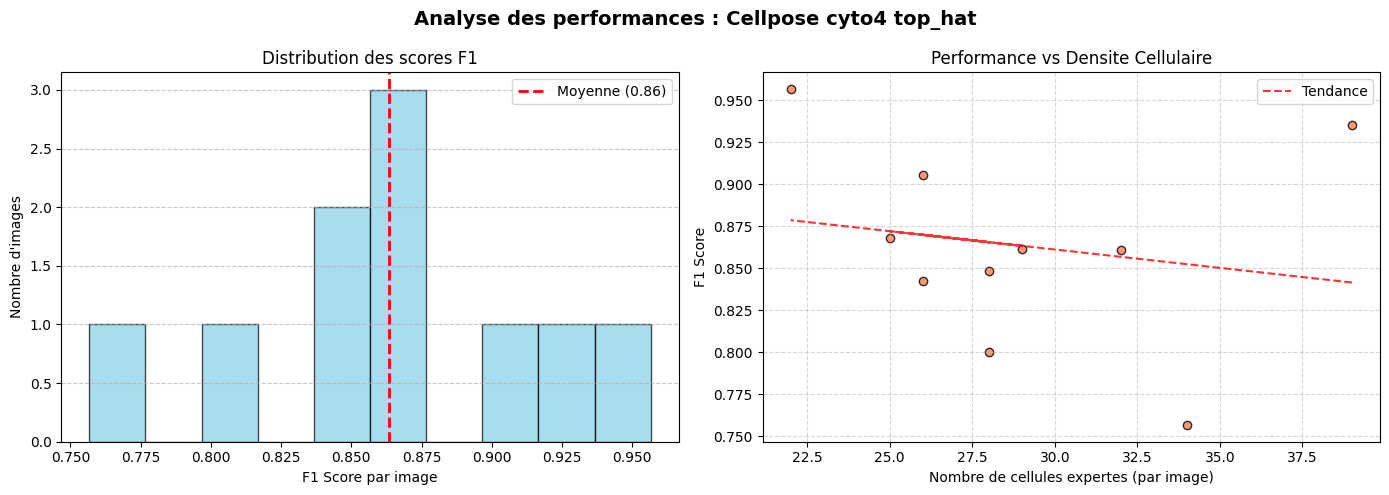

Dossier cellpose4_top_hat envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_top_hat.zip

Évaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()
# modes_experimentaux = ['raw', 'clahe', 'Nuc_Pred']
modes_experimentaux = ['top_hat']
for mode_actuel in modes_experimentaux:
    all_results = [] 
    nom_modele = f'cyto4_40_n4_{mode_actuel.lower()}'
    print(f"\n--- EVAL : target {nom_modele} ---")

    chemin_modele = f'./models/{nom_modele}'
    print(f"Chargement du modèle depuis : {chemin_modele}")
    model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)

    base_output = f'./data/prediction/cellpose4_{mode_actuel.lower()}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    X_val_multi, Y_val_true = visualizer.load_channel(ids_val, target=mode_actuel)

    for idx, img_id in enumerate(ids_val):
        img_stack = X_val_multi[idx]
        true_mask = Y_val_true[idx]
        
        masks, flows, styles = model.eval(
            img_stack, 
            channels=[1, 2], 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=-0.5
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # CORRECTION : Rapport dynamique
        nom_rapport = f"Cellpose_cyto4_{mode_actuel}"

        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        all_results.append(perf)
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Cell')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, target='Cell', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (target : {mode_actuel.upper()}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_cell_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    df_final = ev.global_report(all_results, model_name=f"Cellpose cyto4 {mode_actuel}")
    oc.download_path(base_output,f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_{mode_actuel.lower()}')


print("\nÉvaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.")

creating new log file
2026-03-31 08:45:23,369 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 08:45:23,369 [INFO] 
cellpose version: 	4.1.1.dev3+ga9f8bfcde 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 08:45:23,370 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 08:45:23,371 [INFO] >>>> using GPU (CUDA)
2026-03-31 08:45:25,852 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:04<00:00, 274MB/s]


2026-03-31 08:45:31,692 [INFO] >>> converting bfloat16 network to float32 for training
2026-03-31 08:45:31,702 [INFO] computing flows for labels


100%|██████████| 71/71 [00:02<00:00, 30.18it/s]

2026-03-31 08:45:34,083 [INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 34.14it/s]

2026-03-31 08:45:34,383 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 761.23it/s]

2026-03-31 08:45:34,494 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-03-31 08:45:35,002 [INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-03-31 08:45:35,002 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-03-31 08:45:35,004 [INFO] >>> saving model to models/cellpose4_nuclei
2026-03-31 08:46:04,398 [INFO] 0, train_loss=1.7694, test_loss=1.5357, LR=0.000000, time 29.39s
2026-03-31 08:48:21,543 [INFO] 5, train_loss=0.3692, test_loss=0.1694, LR=0.000006, time 166.54s
2026-03-31 08:50:39,672 [INFO] 10, train_loss=0.1884, test_loss=0.1544, LR=0.000010, time 304.67s
2026-03-31 08:55:14,889 [INFO] 20, train_loss=0.1814, test_loss=0.1491, LR=0.000010, time 579.88s
2026-03-31 08:59:50,026 [INFO] 30, train_loss=0.1707, test_loss=0.1431, LR=0.000010, time 855.02s
2026-03-31 09:03:56,653 [INFO] saving network parameters to models/cellpose4_nuclei
2026-03-31 09:04:04,564 [INFO] >>> converting network back to torch.bfloat16 after training
Modèle sauvegardé : models/cellpose4_nuclei


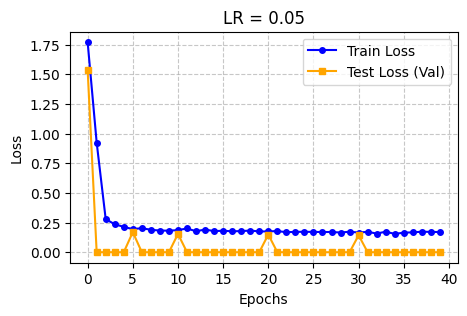

<Axes: title={'center': 'LR = 0.05'}, xlabel='Epochs', ylabel='Loss'>

In [ ]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train, target='Nuc')
X_val,Y_val   = visualizer.load_set(ids_val, target='Nuc')

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate= 1e-5,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cellpose4_nuclei'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


In [ ]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cellpose4_nuclei.pth',
    'models/cellpose4_nuclei', timeout=600                                  
)

2026-03-31 10:14:05,955 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-03-31 10:14:05,955 [INFO] 
cellpose version: 	4.1.1.dev3+ga9f8bfcde 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-03-31 10:14:05,956 [INFO] ** TORCH CUDA version installed and working. **
2026-03-31 10:14:05,957 [INFO] >>>> using GPU (CUDA)
2026-03-31 10:14:07,944 [INFO] >>>> loading model ./models/cellpose4_nuclei.pth
Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...

RESULTATS GLOBAUX : Cellpose4 nuclei ct_-0.5
Images evaluees          : 10
Total Vrais Positifs (TP): 304
Total Faux Positifs (FP) : 124
Total Faux Negatifs (FN) : 29
--------------------------------------------------
F1-Score Global (Micro)  : 0.799
F1-Score Moyen (Macro)   : 0.799



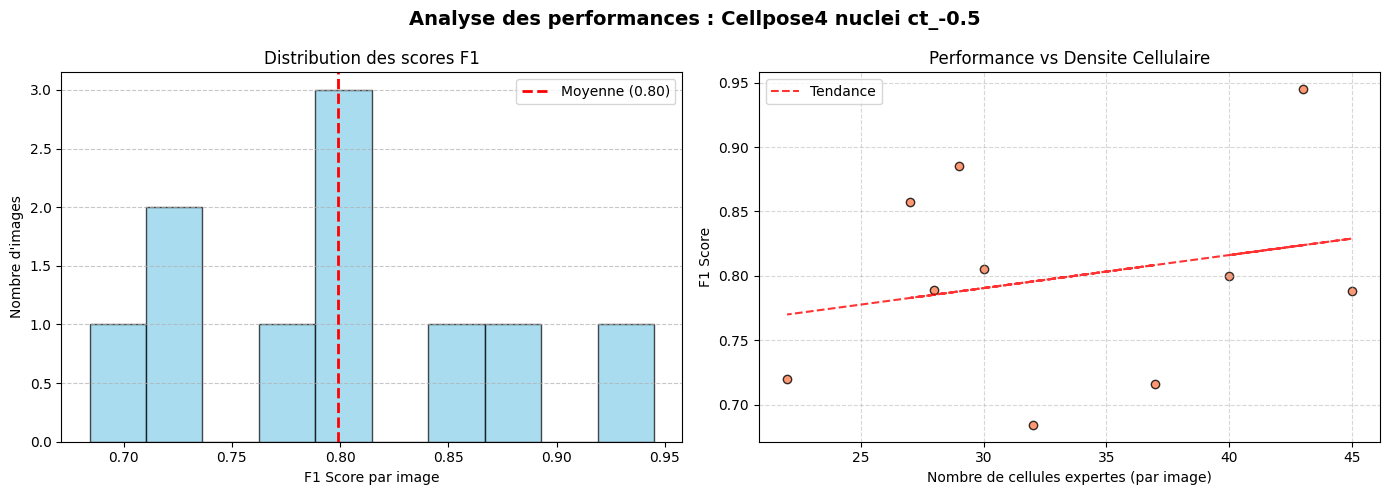

In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model= './models/cellpose4_nuclei.pth')

base_output = './data/prediction/cellpose4_nuclei_ct_-0.5/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, target='Image')
    true_mask = visualizer.load_data(img_id, target='Nuc')
    
    masks, flows, styles = model.eval(img, resample=True,flow_threshold=0.4, cellprob_threshold=-0.5)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Nuc_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Nuc')
    ax2.set_title("B. Superposition ( vert expert, rouge cellpose)")
    
    visualizer.plot(i=img_id, target='Nuc', ax=ax3, show=False)
    ax3.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, target='Nuc_pred', ax=ax4, show=False)
    ax4.set_title("D. Prédiction Cellpose ")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

df_final = ev.global_report(all_results, model_name=f"Cellpose4 nuclei ct_-0.5")

In [14]:
oc.download_path('/content/data/prediction/cellpose4_nuclei_ct_-0.5','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_ct_-0.5')

Dossier cellpose4_nuclei_ct_-0.5 envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_ct_-0.5.zip


In [17]:
import numpy as np

# Mélange aléatoire mais reproductible de vos identifiants
ids_shuffled = np.random.RandomState(42).permutation(ids_train)

# Découpage strict en 4 blocs (arrays)
blocs = np.array_split(ids_shuffled, 4)

# Conversion en listes simples
ids_A = blocs[0].tolist()
ids_B = blocs[1].tolist()
ids_C = blocs[2].tolist()
ids_D = blocs[3].tolist()

In [21]:
print(f"Fold A - Train: {len(ids_A)}")

Fold A - Train: 18



--- Début de l'entraînement pour le Fold A ---
2026-04-03 10:14:29,339 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-03 10:14:29,340 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-03 10:14:29,342 [INFO] ** TORCH CUDA version installed and working. **
2026-04-03 10:14:29,342 [INFO] >>>> using GPU (CUDA)
2026-04-03 10:14:31,706 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-04-03 10:14:32,319 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-03 10:14:32,329 [INFO] computing flows for labels


100%|██████████| 53/53 [00:01<00:00, 32.18it/s]

2026-04-03 10:14:33,997 [INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 33.38it/s]

2026-04-03 10:14:34,302 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 779.19it/s]

2026-04-03 10:14:34,388 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-03 10:14:34,776 [INFO] >>> n_epochs=40, n_train=53, n_test=10
2026-04-03 10:14:34,776 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-03 10:14:34,779 [INFO] >>> saving model to models/cellpose4_nuclei_A
2026-04-03 10:14:55,984 [INFO] 0, train_loss=2.0023, test_loss=1.5357, LR=0.000000, time 21.21s
2026-04-03 10:16:37,779 [INFO] 5, train_loss=0.4316, test_loss=0.1700, LR=0.000006, time 123.00s
2026-04-03 10:18:19,772 [INFO] 10, train_loss=0.2025, test_loss=0.1641, LR=0.000010, time 224.99s
2026-04-03 10:21:42,102 [INFO] 20, train_loss=0.1885, test_loss=0.1506, LR=0.000010, time 427.32s
2026-04-03 10:25:04,466 [INFO] 30, train_loss=0.1811, test_loss=0.1478, LR=0.000010, time 629.69s
2026-04-03 10:28:05,687 [INFO] saving network parameters to models/cellpose4_nuclei_A
2026-04-03 10:28:16,630 [INFO] >>> converting network back to torch.bfloat16 after training
--- Inférence et Évaluation sur le Fold A ---


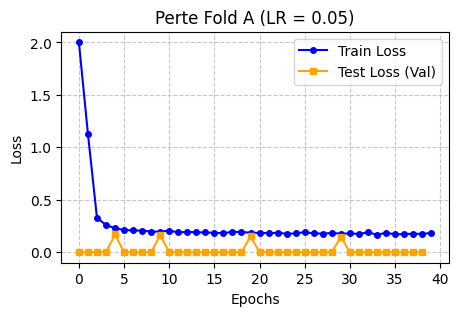

Dossier cellpose4_nuclei_A envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_trainA.zip

--- Début de l'entraînement pour le Fold B ---
2026-04-03 10:29:35,681 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-03 10:29:35,682 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-03 10:29:35,683 [INFO] ** TORCH CUDA version installed and working. **
2026-04-03 10:29:35,684 [INFO] >>>> using GPU (CUDA)
2026-04-03 10:29:37,993 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-04-03 10:29:38,889 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-03 10:29:38,899 [INFO] computing flows for labels


100%|██████████| 53/53 [00:01<00:00, 31.56it/s]

2026-04-03 10:29:40,599 [INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 33.36it/s]

2026-04-03 10:29:40,905 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 752.11it/s]

2026-04-03 10:29:40,990 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-03 10:29:41,380 [INFO] >>> n_epochs=40, n_train=53, n_test=10
2026-04-03 10:29:41,381 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-03 10:29:41,382 [INFO] >>> saving model to models/cellpose4_nuclei_B
2026-04-03 10:30:02,533 [INFO] 0, train_loss=2.3057, test_loss=1.5357, LR=0.000000, time 21.15s
2026-04-03 10:31:44,119 [INFO] 5, train_loss=0.3747, test_loss=0.1754, LR=0.000006, time 122.74s
2026-04-03 10:33:25,753 [INFO] 10, train_loss=0.1906, test_loss=0.1601, LR=0.000010, time 224.37s
2026-04-03 10:36:47,874 [INFO] 20, train_loss=0.1824, test_loss=0.1493, LR=0.000010, time 426.49s
2026-04-03 10:40:10,140 [INFO] 30, train_loss=0.1710, test_loss=0.1451, LR=0.000010, time 628.76s
2026-04-03 10:43:11,332 [INFO] saving network parameters to models/cellpose4_nuclei_B
2026-04-03 10:43:22,451 [INFO] >>> converting network back to torch.bfloat16 after training
--- Inférence et Évaluation sur le Fold B ---


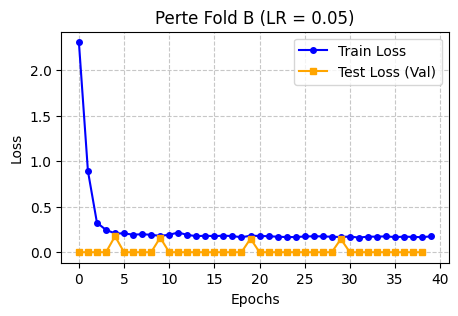

Dossier cellpose4_nuclei_B envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_trainB.zip

--- Début de l'entraînement pour le Fold C ---
2026-04-03 10:44:38,027 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-03 10:44:38,028 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-03 10:44:38,029 [INFO] ** TORCH CUDA version installed and working. **
2026-04-03 10:44:38,030 [INFO] >>>> using GPU (CUDA)
2026-04-03 10:44:40,158 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-04-03 10:44:40,732 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-03 10:44:40,741 [INFO] computing flows for labels


100%|██████████| 53/53 [00:01<00:00, 32.13it/s]

2026-04-03 10:44:42,412 [INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 32.59it/s]

2026-04-03 10:44:42,725 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 735.92it/s]

2026-04-03 10:44:42,810 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-03 10:44:43,200 [INFO] >>> n_epochs=40, n_train=53, n_test=10
2026-04-03 10:44:43,201 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-03 10:44:43,203 [INFO] >>> saving model to models/cellpose4_nuclei_C
2026-04-03 10:45:04,351 [INFO] 0, train_loss=2.1349, test_loss=1.5357, LR=0.000000, time 21.15s
2026-04-03 10:46:45,917 [INFO] 5, train_loss=0.4142, test_loss=0.1692, LR=0.000006, time 122.71s
2026-04-03 10:48:27,554 [INFO] 10, train_loss=0.1945, test_loss=0.1570, LR=0.000010, time 224.35s
2026-04-03 10:51:49,652 [INFO] 20, train_loss=0.1803, test_loss=0.1490, LR=0.000010, time 426.45s
2026-04-03 10:55:12,181 [INFO] 30, train_loss=0.1732, test_loss=0.1451, LR=0.000010, time 628.98s
2026-04-03 10:58:13,407 [INFO] saving network parameters to models/cellpose4_nuclei_C
2026-04-03 10:58:23,918 [INFO] >>> converting network back to torch.bfloat16 after training
--- Inférence et Évaluation sur le Fold C ---


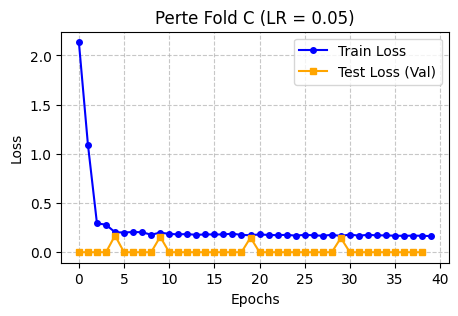

Dossier cellpose4_nuclei_C envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_trainC.zip

--- Début de l'entraînement pour le Fold D ---
2026-04-03 10:59:39,891 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-03 10:59:39,892 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-03 10:59:39,893 [INFO] ** TORCH CUDA version installed and working. **
2026-04-03 10:59:39,894 [INFO] >>>> using GPU (CUDA)
2026-04-03 10:59:41,831 [INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-04-03 10:59:42,389 [INFO] >>> converting bfloat16 network to float32 for training
2026-04-03 10:59:42,399 [INFO] computing flows for labels


100%|██████████| 54/54 [00:01<00:00, 32.49it/s]

2026-04-03 10:59:44,082 [INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 33.67it/s]

2026-04-03 10:59:44,386 [INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 779.47it/s]

2026-04-03 10:59:44,470 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-04-03 10:59:44,862 [INFO] >>> n_epochs=40, n_train=54, n_test=10
2026-04-03 10:59:44,863 [INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-04-03 10:59:44,865 [INFO] >>> saving model to models/cellpose4_nuclei_D
2026-04-03 11:00:06,369 [INFO] 0, train_loss=2.2160, test_loss=1.5357, LR=0.000000, time 21.51s
2026-04-03 11:01:50,243 [INFO] 5, train_loss=0.3877, test_loss=0.1748, LR=0.000006, time 125.38s
2026-04-03 11:03:33,906 [INFO] 10, train_loss=0.1871, test_loss=0.1622, LR=0.000010, time 229.04s
2026-04-03 11:07:00,350 [INFO] 20, train_loss=0.1749, test_loss=0.1507, LR=0.000010, time 435.49s
2026-04-03 11:10:26,771 [INFO] 30, train_loss=0.1671, test_loss=0.1471, LR=0.000010, time 641.91s
2026-04-03 11:13:31,660 [INFO] saving network parameters to models/cellpose4_nuclei_D
2026-04-03 11:13:43,212 [INFO] >>> converting network back to torch.bfloat16 after training
--- Inférence et Évaluation sur le Fold D ---


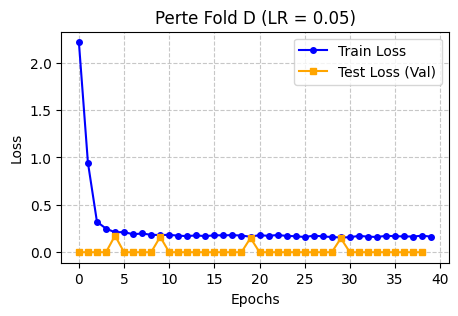

Dossier cellpose4_nuclei_D envoyé vers /travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_trainD.zip
Validation croisée terminée avec succès.


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io

# Itération sur les 4 Folds
for name, ids_ in zip(['A', 'B', 'C', 'D'], [ids_A, ids_B, ids_C, ids_D]):
    print(f"\n--- Début de l'entraînement pour le Fold {name} ---")

    # 1. Exclusion sécurisée du Fold courant pour l'entraînement (Out-of-Fold)
    train_fold_ids = [i for i in ids_train if i not in ids_]
    
    # Chargement des données
    X_train, Y_train = visualizer.load_set(train_fold_ids, target='Nuc')
    X_val, Y_val     = visualizer.load_set(ids_val, target='Nuc')

    base_output = f'./data/prediction/cellpose4_nuclei_{name}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    ev = tool.Stats()
    all_results = [] 

    io.logger_setup()
    model_finetune = models.CellposeModel(gpu=True)

    model_path, t_loss, v_loss = train.train_seg(
        model_finetune.net,
        train_data=X_train,
        train_labels=Y_train,
        test_data=X_val,
        test_labels=Y_val,
        n_epochs=40,          
        learning_rate= 1e-5,
        weight_decay=0.0001,  
        save_path='.',
        model_name=f'cellpose4_nuclei_{name}'
)

    print(f"--- Inférence et Évaluation sur le Fold {name} ---")
    
    # 3. Correction de la variable de boucle
    for img_id in ids_:
        img = visualizer.load_data(img_id, target='Image')
        true_mask = visualizer.load_data(img_id, target='Nuc')
        
        # 4. Appel correct du modèle fine-tuné
        masks, flows, styles = model_finetune.eval(
            img, 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=-0.5
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Nuc_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # Rapport statistique

        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        
        all_results.append(perf)
        # Création de la figure
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Nuc')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, target='Nuc', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, target='Nuc_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (Fold {name}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_nuc_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        
        plt.close(fig)
        
    visualizer.plot_loss(t_loss, v_loss[1:], title=f"Perte Fold {name} (LR = 0.05)", show=True)
    oc.download_path(f'/content/data/prediction/cellpose4_nuclei_{name}', f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_train{name}')

print("Validation croisée terminée avec succès.")

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()
# modes_experimentaux = ['raw', 'clahe', 'Nuc_Pred']
modes_experimentaux = ['Nuc_Pred']
for mode_actuel in modes_experimentaux:
    all_results = [] 
    nom_modele = f'cyto4_40_n4_{mode_actuel.lower()}'
    print(f"\n--- EVAL : target {nom_modele} ---")

    chemin_modele = f'./models/{nom_modele}'
    print(f"Chargement du modèle depuis : {chemin_modele}")
    model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)

    base_output = f'./data/prediction/cellpose4_n4_{mode_actuel.lower()}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    X_val_multi, Y_val_true = visualizer.load_channel(ids_val, mode=mode_actuel, target='Image')

    for idx, img_id in enumerate(ids_val):
        img_stack = X_val_multi[idx]
        true_mask = Y_val_true[idx]
        
        masks, flows, styles = model.eval(
            img_stack, 
            channels=[1, 2], 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=0.0
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # CORRECTION : Rapport dynamique
        nom_rapport = f"Cellpose_cyto4_n4_{mode_actuel}"

        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        all_results.append(perf)
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Cell')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, target='Cell', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (target : {mode_actuel.upper()}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_cell_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    df_final = ev.global_report(all_results, model_name=f"Cellpose cyto4 n4 {mode_actuel}")
    oc.download_path(base_output,f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_n4_{mode_actuel.lower()}')


print("\nÉvaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.")

2026-04-07 12:42:01,934 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-07 12:42:01,934 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128

--- EVAL : MODE cyto4_40_n4_nuc_pred ---
Chargement du modèle depuis : ./models/cyto4_40_n4_nuc_pred
2026-04-07 12:42:01,937 [INFO] ** TORCH CUDA version installed and working. **
2026-04-07 12:42:01,937 [INFO] >>>> using GPU (CUDA)
2026-04-07 12:42:01,938 [WARNING] pretrained model /root/.cellpose/models/cpsam not found, using default model
2026-04-07 12:42:04,131 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:04<00:00, 303MB/s]


StopIteration: 

2026-04-14 12:51:45,518 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-04-14 12:51:45,519 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-04-14 12:51:45,520 [INFO] ** TORCH CUDA version installed and working. **
2026-04-14 12:51:45,520 [INFO] >>>> using GPU (CUDA)
2026-04-14 12:51:47,478 [INFO] >>>> loading model ./models/cellpose4_nuclei.pth
Calcul en cours : Flow: 0.0 | CellProb: -0.6...
Calcul en cours : Flow: 0.0 | CellProb: -0.5...
Calcul en cours : Flow: 0.3 | CellProb: -0.6...
Calcul en cours : Flow: 0.3 | CellProb: -0.5...
Calcul en cours : Flow: 0.4 | CellProb: -0.6...
Calcul en cours : Flow: 0.4 | CellProb: -0.5...
Calcul en cours : Flow: 0.5 | CellProb: -0.6...
Calcul en cours : Flow: 0.5 | CellProb: -0.5...


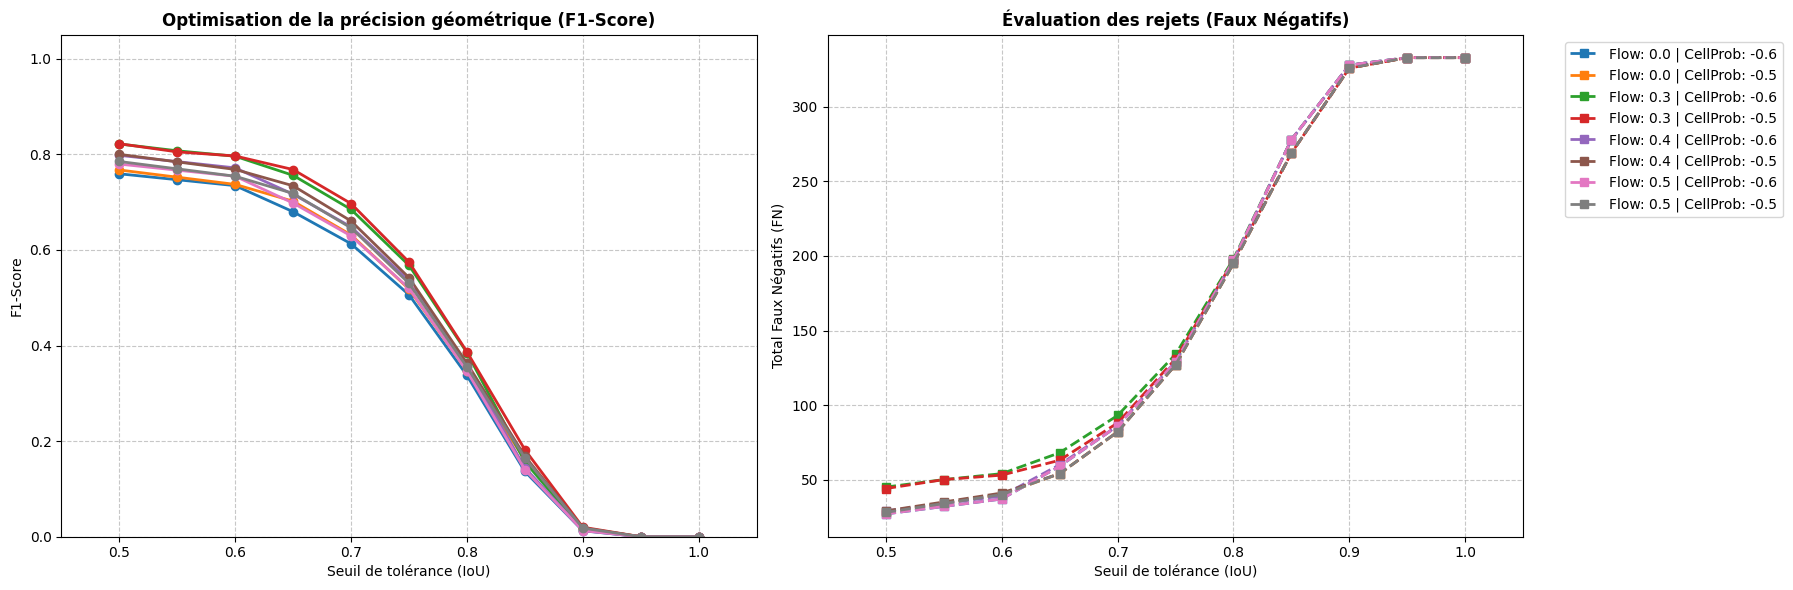


--- GÉNÉRATION DES RAPPORTS DÉTAILLÉS ---

Report pour Flow: 0.0 | CellProb: -0.6 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.0 | CellProb: -0.6
Images evaluees          : 10
Total Vrais Positifs (TP): 306
Total Faux Positifs (FP) : 167
Total Faux Negatifs (FN) : 27
--------------------------------------------------
F1-Score Global (Micro)  : 0.759
F1-Score Moyen (Macro)   : 0.759



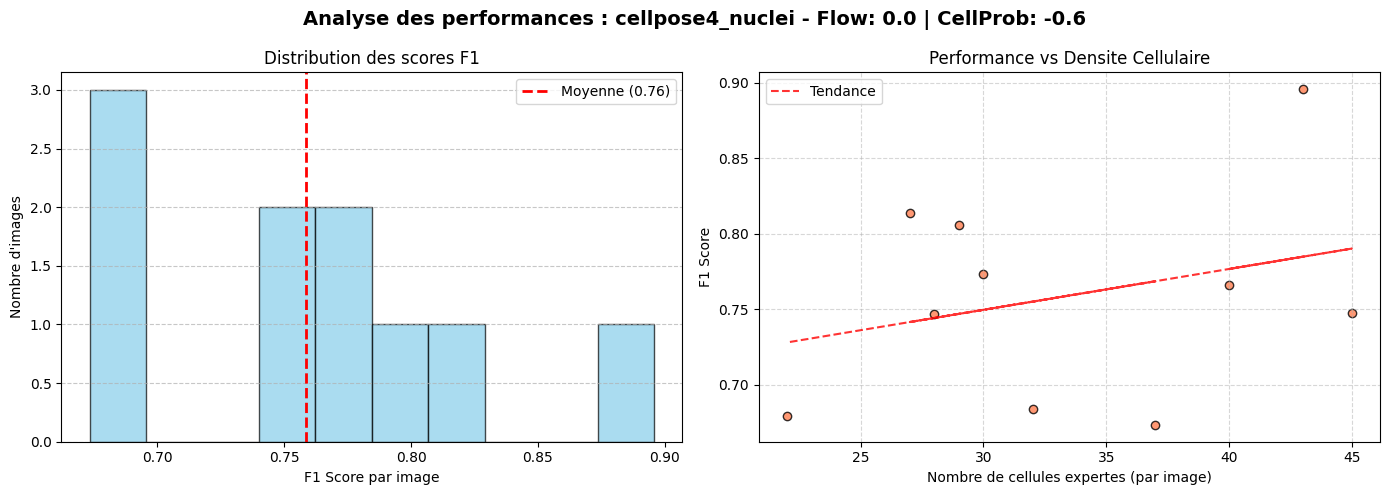


Report pour Flow: 0.0 | CellProb: -0.5 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.0 | CellProb: -0.5
Images evaluees          : 10
Total Vrais Positifs (TP): 305
Total Faux Positifs (FP) : 157
Total Faux Negatifs (FN) : 28
--------------------------------------------------
F1-Score Global (Micro)  : 0.767
F1-Score Moyen (Macro)   : 0.767



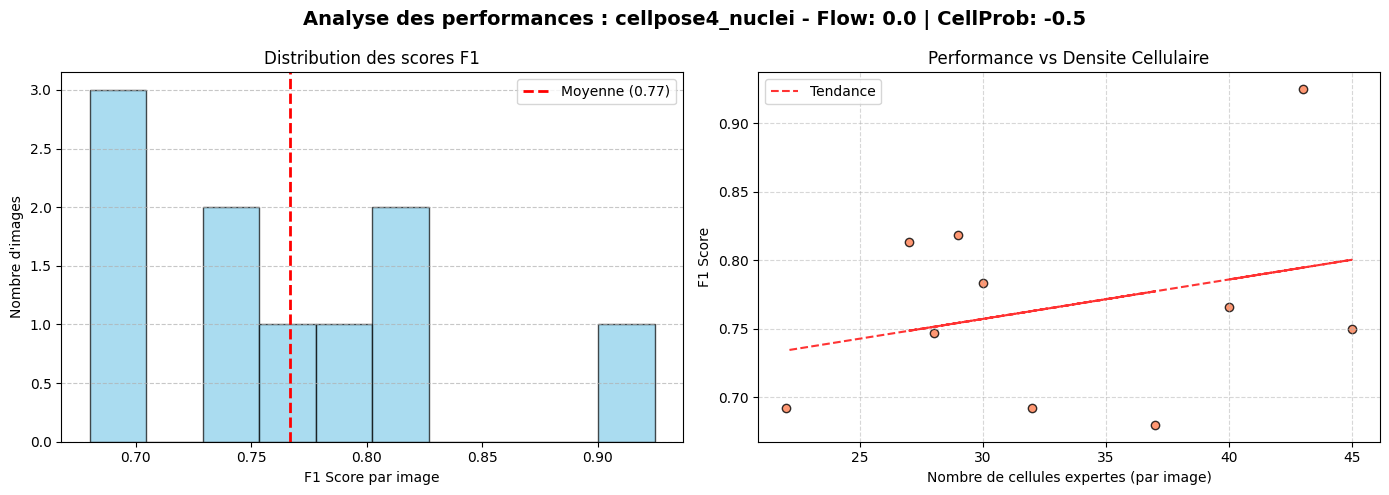


Report pour Flow: 0.3 | CellProb: -0.6 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.3 | CellProb: -0.6
Images evaluees          : 10
Total Vrais Positifs (TP): 288
Total Faux Positifs (FP) : 80
Total Faux Negatifs (FN) : 45
--------------------------------------------------
F1-Score Global (Micro)  : 0.822
F1-Score Moyen (Macro)   : 0.825



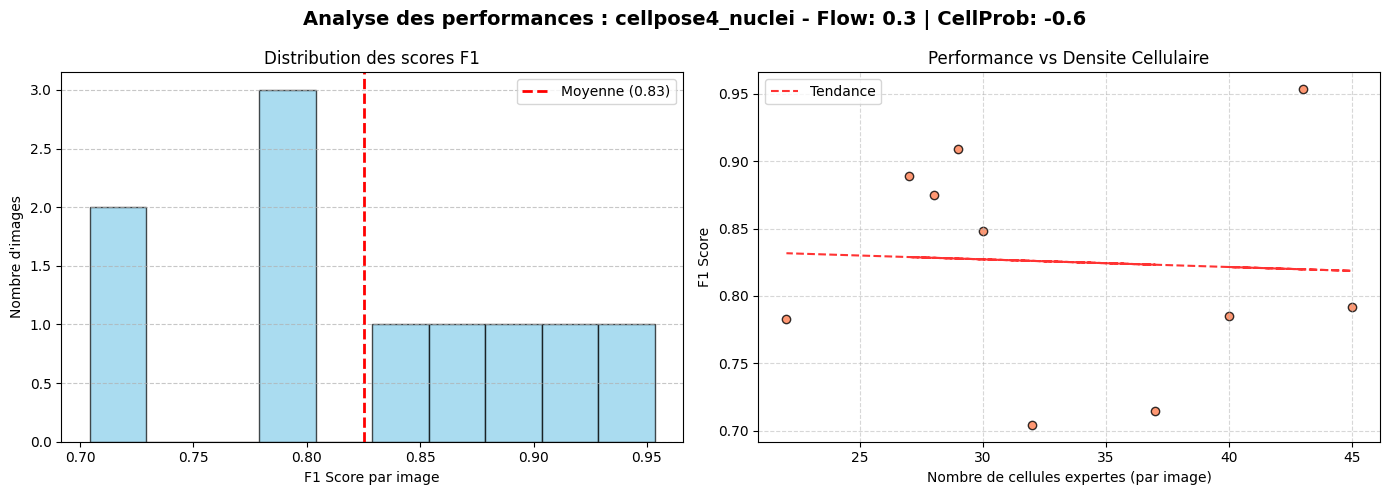


Report pour Flow: 0.3 | CellProb: -0.5 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.3 | CellProb: -0.5
Images evaluees          : 10
Total Vrais Positifs (TP): 289
Total Faux Positifs (FP) : 81
Total Faux Negatifs (FN) : 44
--------------------------------------------------
F1-Score Global (Micro)  : 0.822
F1-Score Moyen (Macro)   : 0.826



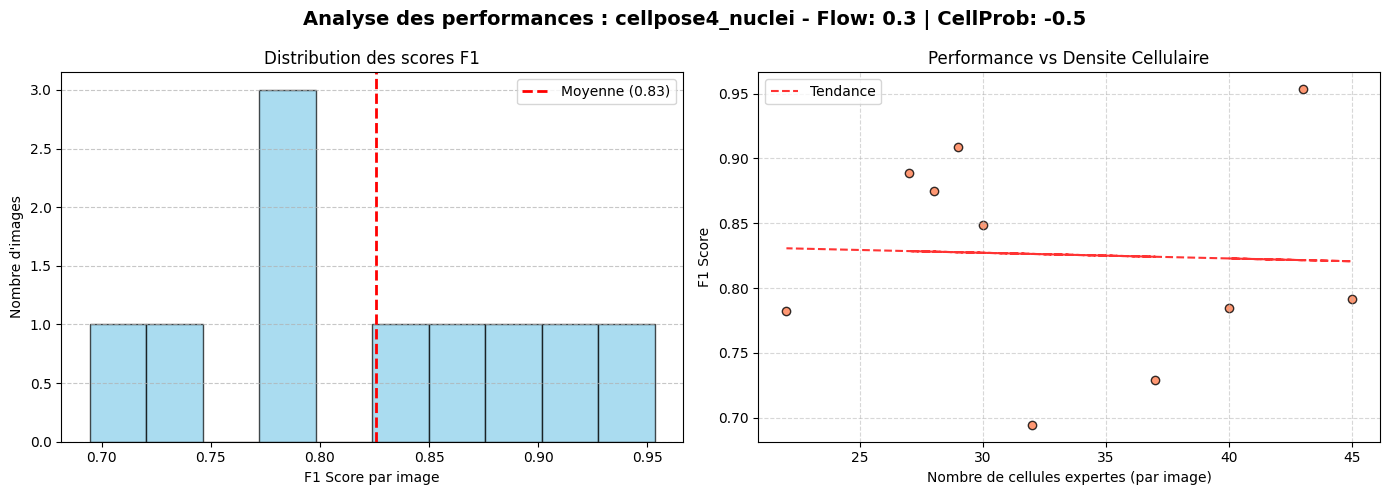


Report pour Flow: 0.4 | CellProb: -0.6 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.4 | CellProb: -0.6
Images evaluees          : 10
Total Vrais Positifs (TP): 304
Total Faux Positifs (FP) : 125
Total Faux Negatifs (FN) : 29
--------------------------------------------------
F1-Score Global (Micro)  : 0.798
F1-Score Moyen (Macro)   : 0.798



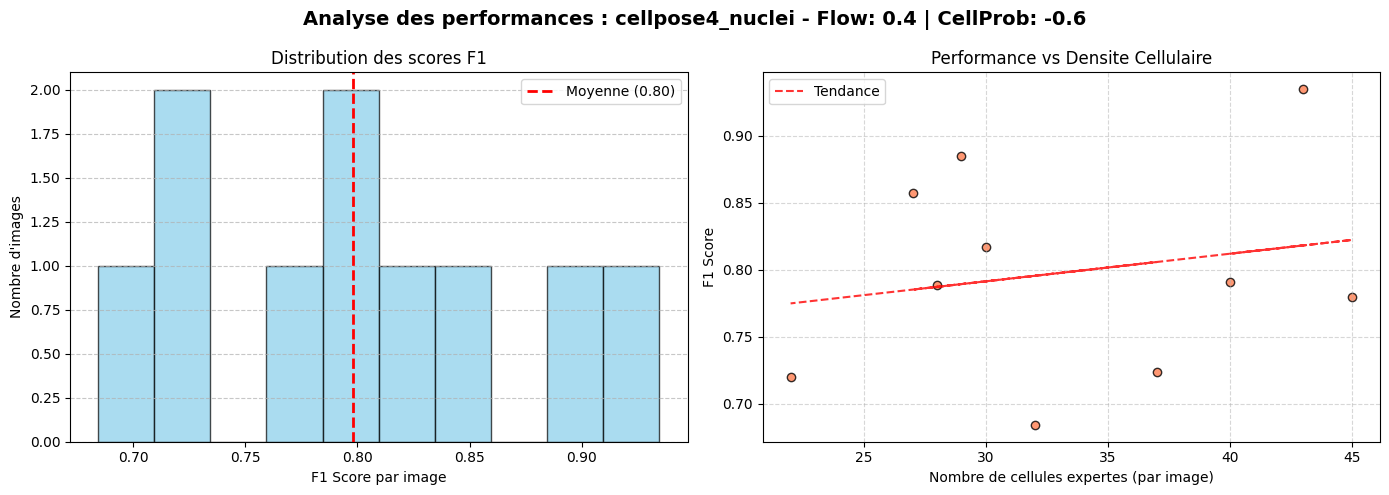


Report pour Flow: 0.4 | CellProb: -0.5 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.4 | CellProb: -0.5
Images evaluees          : 10
Total Vrais Positifs (TP): 304
Total Faux Positifs (FP) : 123
Total Faux Negatifs (FN) : 29
--------------------------------------------------
F1-Score Global (Micro)  : 0.800
F1-Score Moyen (Macro)   : 0.800



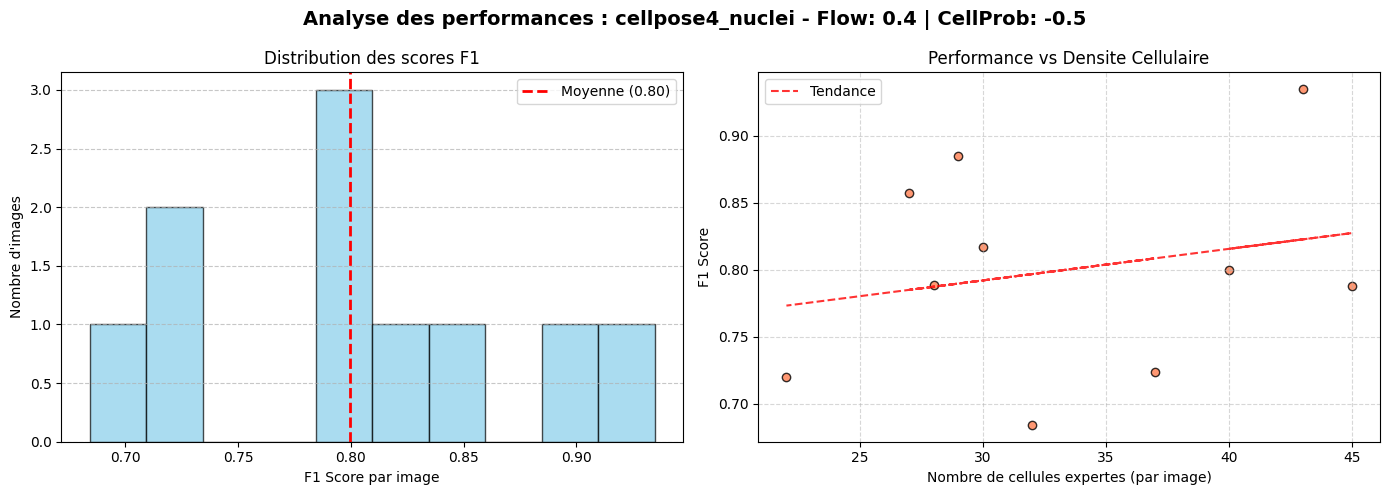


Report pour Flow: 0.5 | CellProb: -0.6 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.5 | CellProb: -0.6
Images evaluees          : 10
Total Vrais Positifs (TP): 306
Total Faux Positifs (FP) : 146
Total Faux Negatifs (FN) : 27
--------------------------------------------------
F1-Score Global (Micro)  : 0.780
F1-Score Moyen (Macro)   : 0.780



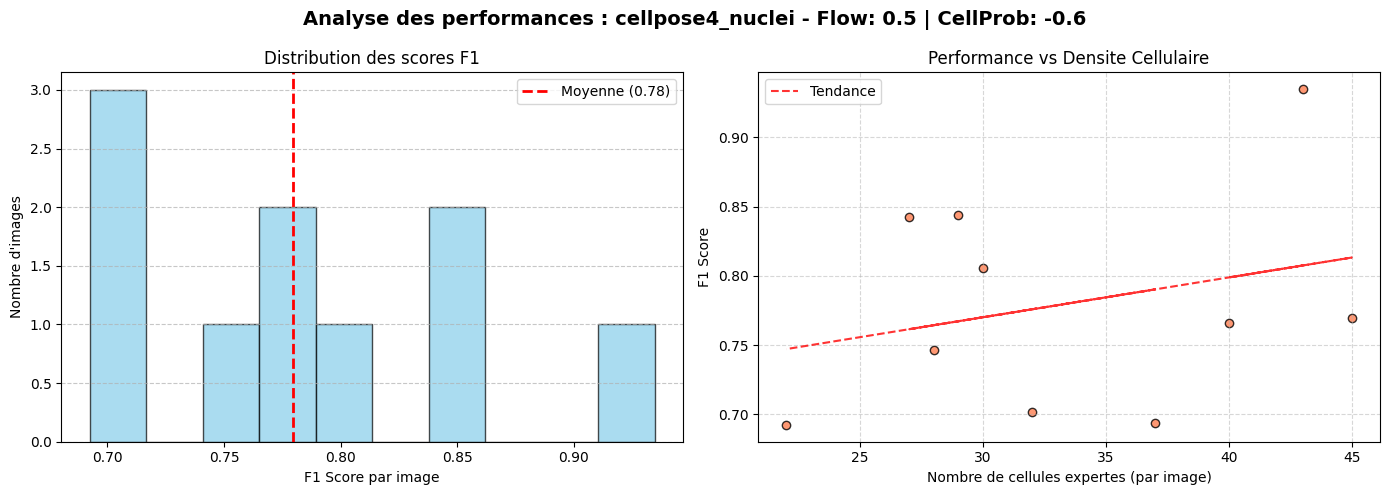


Report pour Flow: 0.5 | CellProb: -0.5 :

RESULTATS GLOBAUX : cellpose4_nuclei - Flow: 0.5 | CellProb: -0.5
Images evaluees          : 10
Total Vrais Positifs (TP): 305
Total Faux Positifs (FP) : 139
Total Faux Negatifs (FN) : 28
--------------------------------------------------
F1-Score Global (Micro)  : 0.785
F1-Score Moyen (Macro)   : 0.785



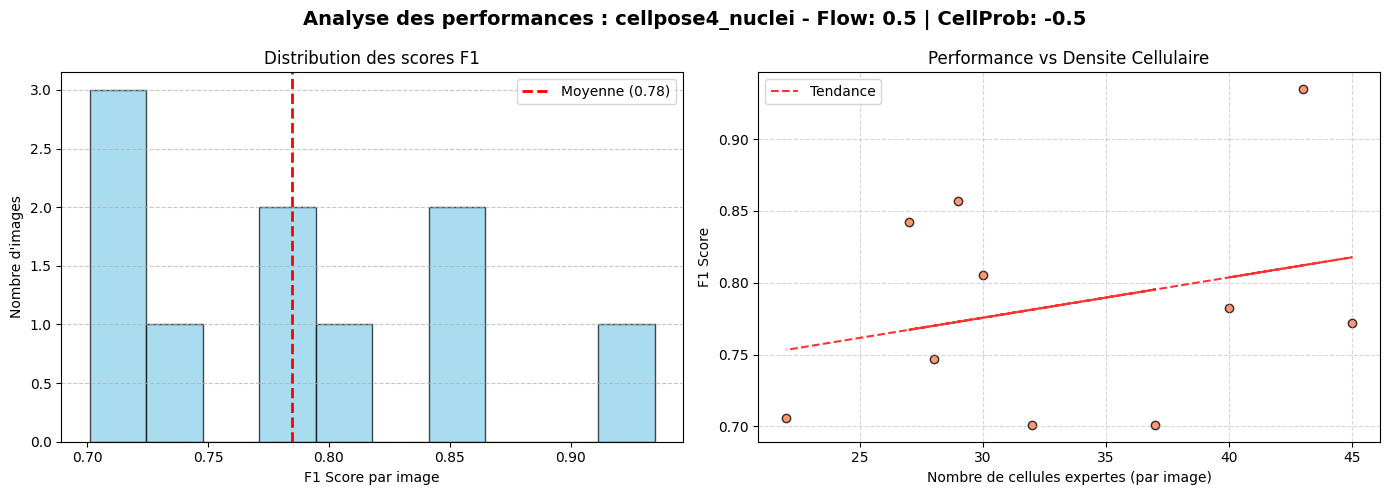

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()

mode_actuel = 'Nuc'
nom_modele = f'cellpose4_nuclei'
chemin_modele = './models/cellpose4_nuclei.pth'

model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)
# X_val_multi, Y_val_true = visualizer.load_channel(ids_val, target=mode_actuel)

X_val_multi, Y_val_true = visualizer.load_set(ids_val, target='Nuc')


# Grille de recherche
flow_thresholds = [0.0,0.3,0.4, 0.5]
cellprob_thresholds = [ -0.6,-0.5]

# Initialisation de DEUX subplots
fig, (ax_f1, ax_fn) = plt.subplots(1, 2, figsize=(18, 6))

# CORRECTION : Création du dictionnaire d'archivage
stockage_resultats_bruts = {}

for f_t in flow_thresholds:
    for c_t in cellprob_thresholds:

        # CORRECTION : Nom de variable unifié
        all_results_combinaison = [] 
        masks_pred_list = [] 

        nom_complet = f"Flow: {f_t} | CellProb: {c_t}"
        print(f"Calcul en cours : {nom_complet}...")

        for idx, img_id in enumerate(ids_val):
            img_stack = X_val_multi[idx]
            true_mask = Y_val_true[idx]
            
            masks, _, _ = model.eval(
                img_stack, 
                # channels=[1, 2], 
                resample=True, 
                flow_threshold=f_t, 
                cellprob_threshold=c_t
            )
            
            masks_pred_list.append(masks)
            all_results_combinaison.append(perf := ev.summary_perf(true_mask, masks, iou_threshold=0.5))

        # On trace la courbe sur l'axe de comparaison
        ev.plot_f1_vs_iou(Y_val_true, masks_pred_list, ax=(ax_f1, ax_fn), show=False)
        
        if ax_f1.lines:
            ax_f1.lines[-1].set_label(nom_complet)
            ax_fn.lines[-1].set_label(nom_complet)
            
        # CORRECTION : Archivage des résultats pour cette combinaison
        stockage_resultats_bruts[nom_complet] = all_results_combinaison

# Formatage final global
ax_f1.set_title("Optimisation de la précision géométrique (F1-Score)", fontweight='bold')
ax_fn.set_title("Évaluation des rejets (Faux Négatifs)", fontweight='bold')

# Une seule légende placée sur le second graphique
ax_fn.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Génération successive de tous les rapports globaux
print("\n--- GÉNÉRATION DES RAPPORTS DÉTAILLÉS ---")
for nom_complet, resultats in stockage_resultats_bruts.items():
    print(f"\nReport pour {nom_complet} :")
    df_final = ev.global_report(resultats, model_name=f"{nom_modele} - {nom_complet}")